# Capítulo 040 — Armar un informe breve de análisis exploratorio

## Del análisis al informe

En los capítulos anteriores analizamos el dataset `tips` desde distintas perspectivas: revisamos su estructura, resumimos variables numéricas, contamos categorías, comparamos grupos, construimos visualizaciones y escribimos conclusiones prudentes a partir de los resultados.

En este capítulo vamos a dar un paso más: organizar esos resultados en un informe breve de análisis exploratorio.

Un informe no tiene que incluir todo lo que hicimos durante el análisis. Al contrario, una parte importante del trabajo consiste en seleccionar qué resultados son realmente útiles para responder una pregunta o comunicar una idea principal. Por eso, el foco de este capítulo no estará en aplicar muchas herramientas nuevas, sino en ordenar, elegir y presentar mejor la información.

Vamos a trabajar con una estructura simple:

- propósito del informe;
- breve descripción del dataset;
- resultados principales;
- visualizaciones relevantes;
- conclusiones;
- límites del análisis.

La idea es construir un informe claro, breve y honesto con los datos disponibles.

## Datos de referencia

Vamos a seguir trabajando con el dataset `tips`, ya analizado en capítulos anteriores. Sabemos que contiene 244 registros y 7 columnas, con información sobre cuentas, propinas, día, horario, tamaño de mesa y algunas variables categóricas asociadas.

En este capítulo no vamos a volver a explorar el dataset desde cero. Vamos a usar esos resultados conocidos como base para armar un informe breve de análisis exploratorio.

La siguiente celda solo carga las librerías y el dataset; no produce salida visible:

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("tips")

## Definir el propósito del informe

Antes de elegir tablas, gráficos o conclusiones, conviene definir qué quiere comunicar el informe. Un análisis exploratorio puede producir muchos resultados, pero un informe breve necesita seleccionar solo los más importantes.

En este caso, vamos a armar un informe con este propósito:

**Describir los patrones generales de cuentas y propinas en el dataset `tips`, prestando atención a las diferencias por día y horario, y a la relación entre el importe total de la cuenta y la propina.**

Este propósito nos ayuda a decidir qué incluir y qué dejar afuera. Por ejemplo, no necesitamos mostrar todas las tablas posibles ni repetir cada gráfico trabajado en capítulos anteriores. Vamos a seleccionar algunos resultados que permitan responder estas preguntas:

- ¿cómo se distribuyen los importes de las cuentas y las propinas?
- ¿hay diferencias relevantes entre días u horarios?
- ¿qué relación aparece entre el importe total de la cuenta y la propina?
- ¿qué límites debemos tener en cuenta al interpretar estos resultados?

Con esta orientación, el informe será breve, pero no será una simple acumulación de números.

## Seleccionar resultados relevantes

Una vez definido el propósito, el siguiente paso es elegir qué resultados vamos a usar. En un informe breve, seleccionar es tan importante como calcular.

Para este informe vamos a recuperar algunos resultados ya conocidos y organizarlos en tablas pequeñas:

- un resumen general de las variables numéricas principales;
- una comparación por horario;
- una comparación por día.

Estas tablas no serán el informe completo. No buscamos rehacer todo el análisis, sino recuperar una base mínima para elegir qué comunicar.

In [4]:
resumen_general = df[["total_bill", "tip", "size"]].agg(["mean", "median", "min", "max"]).round(2)

resumen_por_horario = (
    df.groupby("time", observed=True)
    .agg(
        cantidad_cuentas=("total_bill", "count"),
        promedio_cuenta=("total_bill", "mean"),
        mediana_cuenta=("total_bill", "median"),
        promedio_propina=("tip", "mean")
    )
    .round(2)
)

resumen_por_dia = (
    df.groupby("day", observed=True)
    .agg(
        cantidad_cuentas=("total_bill", "count"),
        promedio_cuenta=("total_bill", "mean"),
        mediana_cuenta=("total_bill", "median"),
        promedio_propina=("tip", "mean")
    )
    .round(2)
)

display(resumen_general)
display(resumen_por_horario)
display(resumen_por_dia)

,total_bill,tip,size
mean,19.79,3.0,2.57
median,17.80,2.9,2.00
min,3.07,1.0,1.00
max,50.81,10.0,6.00


,cantidad_cuentas,promedio_cuenta,mediana_cuenta,promedio_propina
time,,,,
Lunch,68,17.17,15.96,2.73
Dinner,176,20.80,18.39,3.10


,cantidad_cuentas,promedio_cuenta,mediana_cuenta,promedio_propina
day,,,,
Thur,62,17.68,16.20,2.77
Fri,19,17.15,15.38,2.73
Sat,87,20.44,18.24,2.99
Sun,76,21.41,19.63,3.26


## Interpretar qué resultados conviene usar

Las tablas anteriores resumen varios resultados útiles, pero un informe breve no debería limitarse a pegarlas una detrás de otra. Primero conviene identificar qué información aporta cada una.

El resumen general muestra que las cuentas tienen una media de 19.79 y una mediana de 17.80. Como la media es algo mayor que la mediana y el valor máximo llega a 50.81, los datos sugieren que hay algunas cuentas altas que empujan el promedio hacia arriba. Algo parecido ocurre con las propinas: la mayoría se ubica en valores bajos o medios, aunque aparecen algunos valores más altos.

La comparación por horario muestra que `Dinner` concentra más registros que `Lunch` y también presenta un promedio de cuenta más alto. Esta diferencia puede ser relevante para el informe, pero debe interpretarse considerando que los grupos no tienen el mismo tamaño.

La comparación por día muestra que `Sun` y `Sat` tienen los promedios de cuenta más altos, mientras que `Thur` y `Fri` tienen valores más bajos. En particular, `Fri` debe leerse con cuidado porque tiene pocos registros en comparación con los otros días.

A partir de esto, para el informe breve conviene seleccionar tres ideas principales:

- la distribución general de cuentas y propinas;
- las diferencias entre días y horarios;
- la relación entre el importe total de la cuenta y la propina.

## Elegir visualizaciones para el informe

Un informe breve no necesita incluir todos los gráficos posibles. Es mejor elegir pocas visualizaciones, pero que acompañen directamente las ideas principales.

Primero vamos a incluir una visualización sobre la distribución de `total_bill` y `tip`. Esto permite mostrar cómo se concentran los valores y si aparecen algunos casos altos menos frecuentes.

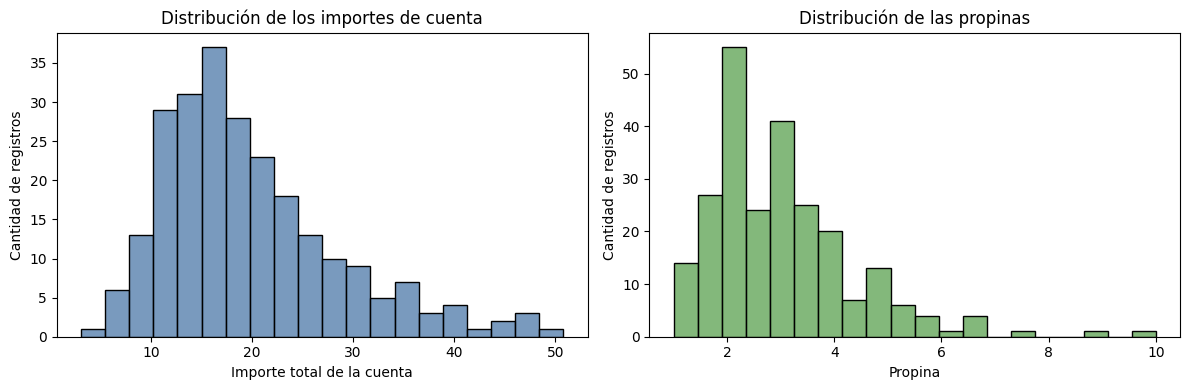

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df, x="total_bill", bins=20, ax=axes[0], color="#4C78A8")
axes[0].set_title("Distribución de los importes de cuenta")
axes[0].set_xlabel("Importe total de la cuenta")
axes[0].set_ylabel("Cantidad de registros")

sns.histplot(data=df, x="tip", bins=20, ax=axes[1], color="#59A14F")
axes[1].set_title("Distribución de las propinas")
axes[1].set_xlabel("Propina")
axes[1].set_ylabel("Cantidad de registros")

plt.tight_layout()
plt.show()

Los histogramas muestran que `total_bill` y `tip` no se distribuyen de manera uniforme. En ambos casos, la mayor parte de los registros se concentra en valores bajos o medios, mientras que los valores más altos aparecen con menor frecuencia.

En `total_bill`, la concentración principal se observa aproximadamente entre importes de 10 y 25, con una cola hacia valores más altos. En `tip`, la mayor concentración aparece entre propinas cercanas a 2 y 4, aunque existen algunos casos aislados con propinas más altas.

Para el informe breve, esta visualización puede servir para comunicar una primera idea general: dentro de los datos analizados, las cuentas y propinas más frecuentes se ubican en rangos moderados, pero hay algunos valores altos que conviene tener presentes al interpretar promedios.

## Visualizar diferencias por día y horario

Después de observar la distribución general, podemos elegir una visualización que ayude a comparar grupos. Como el propósito del informe incluye diferencias por día y horario, vamos a construir gráficos de barras con el promedio de cuenta según estas variables.

Estos gráficos no reemplazan a las tablas anteriores, pero ayudan a comunicar el patrón principal de manera más rápida.

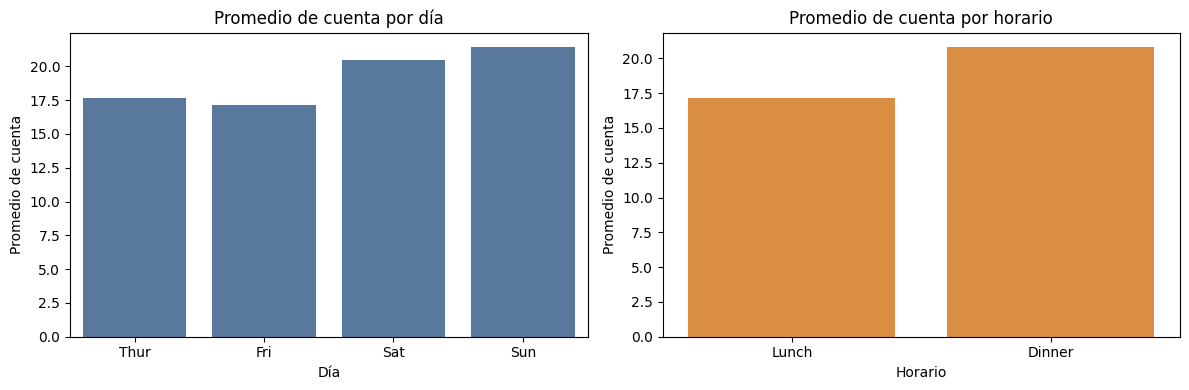

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

orden_dias = ["Thur", "Fri", "Sat", "Sun"]

sns.barplot(data=df, x="day", y="total_bill", order=orden_dias, errorbar=None, ax=axes[0], color="#4C78A8")
axes[0].set_title("Promedio de cuenta por día")
axes[0].set_xlabel("Día")
axes[0].set_ylabel("Promedio de cuenta")

sns.barplot(data=df, x="time", y="total_bill", errorbar=None, ax=axes[1], color="#F28E2B")
axes[1].set_title("Promedio de cuenta por horario")
axes[1].set_xlabel("Horario")
axes[1].set_ylabel("Promedio de cuenta")

plt.tight_layout()
plt.show()

Los gráficos de barras muestran que el promedio de cuenta es más alto en `Sun` y `Sat` que en `Thur` y `Fri`. También se observa que `Dinner` tiene un promedio de cuenta más alto que `Lunch`.

Estos resultados son útiles para el informe porque resumen diferencias entre grupos de manera visual. Sin embargo, deben interpretarse junto con las cantidades de registros vistas antes: `Fri` tiene pocos casos y `Dinner` tiene muchos más registros que `Lunch`.

Por eso, en el informe no alcanza con decir que un grupo tiene mayor promedio. También conviene aclarar si la comparación está apoyada en grupos de tamaños similares o si requiere cautela.

## Visualizar la relación entre cuenta y propina

El tercer resultado importante para el informe es la relación entre el importe total de la cuenta y la propina. Para comunicarlo, podemos usar un gráfico de dispersión.

Este gráfico permite observar si, dentro del dataset, las cuentas más altas tienden a estar asociadas con propinas más altas.

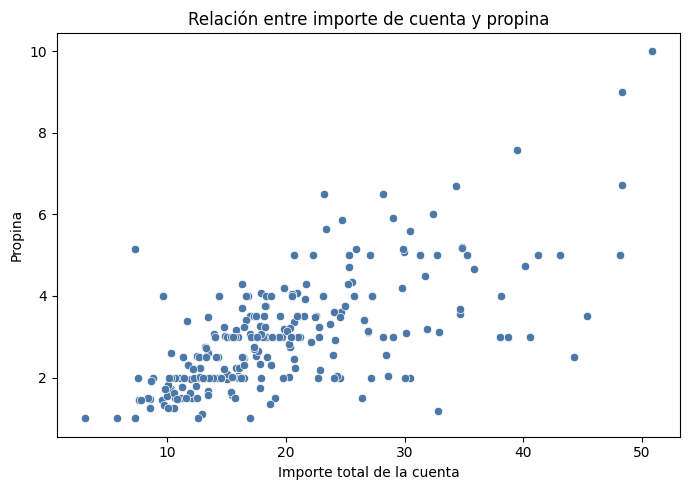

In [7]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip",
    color="#4C78A8"
)

plt.title("Relación entre importe de cuenta y propina")
plt.xlabel("Importe total de la cuenta")
plt.ylabel("Propina")
plt.tight_layout()
plt.show()

El gráfico de dispersión muestra una relación positiva entre `total_bill` y `tip`: en general, las cuentas de mayor importe tienden a estar asociadas con propinas más altas.

De todos modos, la relación no es perfecta. Para importes similares aparecen propinas diferentes, y también hay algunos casos alejados del conjunto principal de puntos. Por eso, esta visualización permite comunicar una tendencia general, pero no alcanza para explicar por sí sola por qué se deja una determinada propina.

En el informe breve, este gráfico puede acompañar una conclusión prudente: dentro de los datos analizados, existe una asociación positiva entre el importe total de la cuenta y la propina, sin afirmar causalidad.

## Organizar el informe

Ahora que seleccionamos los resultados principales, podemos ordenar el informe. Una estructura breve y clara podría ser:

1. **Propósito del análisis**  
   Explicar qué se quiere observar en el dataset.

2. **Descripción general de los datos**  
   Presentar el dataset de manera breve, sin repetir toda la exploración inicial.

3. **Resultados principales**  
   Incluir los hallazgos más importantes sobre distribuciones, diferencias entre grupos y relación entre variables.

4. **Conclusiones**  
   Integrar los resultados en una lectura general.

5. **Límites del análisis**  
   Aclarar qué aspectos deben interpretarse con cuidado.

Esta estructura ayuda a que el informe no sea una sucesión de tablas y gráficos sin conexión. Cada parte cumple una función dentro del texto.

## Decidir qué dejar afuera

Armar un informe también implica descartar información. Durante un análisis exploratorio podemos generar muchas tablas, gráficos y comparaciones, pero no todas tienen la misma importancia para comunicar el resultado final.

En este informe no vamos a incluir todas las salidas posibles del análisis de `tips`. Por ejemplo, no hace falta repetir cada conteo de categorías ni todos los gráficos construidos en capítulos anteriores. Tampoco necesitamos mostrar todas las combinaciones entre variables si no aportan directamente al propósito definido.

Para mantener el informe breve, vamos a priorizar:

- la distribución general de cuentas y propinas;
- las diferencias principales por día y horario;
- la relación entre importe de cuenta y propina;
- las precauciones necesarias para interpretar esos resultados.

Esta selección permite construir un informe más claro y enfocado.

## Informe breve de análisis exploratorio

### Propósito del análisis

El propósito de este informe es describir algunos patrones generales del dataset `tips`, prestando atención a los importes de las cuentas, las propinas, las diferencias por día y horario, y la relación entre el importe total de la cuenta y la propina.

No se busca explicar causalmente el comportamiento de las propinas, sino resumir los principales resultados observados durante el análisis exploratorio.

### Descripción general del dataset

El dataset contiene 244 registros y 7 columnas. Cada registro representa una cuenta e incluye información como el importe total (`total_bill`), la propina (`tip`), el día (`day`), el horario (`time`) y el tamaño de la mesa (`size`), entre otras variables.

Como se trata de un dataset acotado y ya preparado para el análisis, los resultados deben interpretarse dentro de ese alcance. No contamos, por ejemplo, con información detallada sobre el período de recolección, el tipo de restaurante o el contexto en que se registraron los datos.

### Resultados principales

En primer lugar, los importes de las cuentas se concentran principalmente en valores bajos o medios. La media de `total_bill` es 19.79 y la mediana es 17.80, mientras que el valor máximo llega a 50.81. Esto sugiere que hay algunas cuentas altas que pueden influir sobre el promedio.

Algo similar ocurre con las propinas. La media de `tip` es 3.00 y la mediana es 2.90, con un valor máximo de 10.00. Los histogramas muestran que la mayoría de las propinas se ubica en valores moderados, aunque existen algunos casos más altos.

Al comparar por horario, `Dinner` concentra más registros que `Lunch` y también presenta un promedio de cuenta más alto. En los datos analizados, el promedio de `total_bill` es 20.80 para `Dinner` y 17.17 para `Lunch`. Esta diferencia debe interpretarse considerando que los grupos no tienen el mismo tamaño: `Dinner` tiene 176 registros, mientras que `Lunch` tiene 68.

También aparecen diferencias entre días. `Sun` y `Sat` presentan los promedios de cuenta más altos, con valores de 21.41 y 20.44 respectivamente. `Thur` y `Fri` tienen promedios menores, aunque `Fri` debe leerse con especial cuidado porque solo cuenta con 19 registros.

Por último, el gráfico de dispersión entre `total_bill` y `tip` muestra una relación positiva: en general, las cuentas de mayor importe tienden a estar asociadas con propinas más altas. Sin embargo, la relación no es perfecta y no permite afirmar causalidad.

### Conclusiones

Dentro de los datos analizados, las cuentas y propinas se concentran principalmente en valores bajos o medios, con algunos valores altos menos frecuentes. También se observan diferencias por día y horario: `Dinner` presenta un promedio de cuenta más alto que `Lunch`, y `Sun` y `Sat` muestran los promedios más altos entre los días registrados.

Además, existe una asociación positiva entre el importe total de la cuenta y la propina. Esto significa que, en general, las cuentas más altas tienden a estar acompañadas por propinas más altas, aunque la variabilidad observada indica que esa relación no es exacta.

### Límites del análisis

Estos resultados deben interpretarse con prudencia. El dataset tiene un tamaño limitado y algunos grupos, como `Fri`, cuentan con pocos registros. Además, no todos los días y horarios están representados de la misma manera, por lo que algunas comparaciones pueden estar influidas por el desbalance entre grupos.

También es importante recordar que el análisis exploratorio permite identificar patrones y relaciones, pero no demuestra causas. Para explicar por qué algunas cuentas tienen propinas más altas que otras, haría falta contar con más información contextual y aplicar otros tipos de análisis.

## Revisar si el informe cumple su propósito

Después de escribir una primera versión del informe, conviene revisarlo con algunas preguntas simples.

La primera pregunta es si el informe responde al propósito definido al comienzo. En este caso, el objetivo era describir patrones generales de cuentas y propinas, observar diferencias por día y horario, y comentar la relación entre `total_bill` y `tip`. El informe se mantiene dentro de ese eje y no intenta explicar temas que no fueron analizados.

La segunda pregunta es si los resultados seleccionados son suficientes, pero no excesivos. El informe no incluye todas las tablas ni todos los gráficos posibles, sino solo los resultados que ayudan a comunicar las ideas principales. Esto lo hace más claro para quien lee.

La tercera pregunta es si las conclusiones son prudentes. En el texto se usan expresiones como “dentro de los datos analizados”, “tienden a” y “debe interpretarse con prudencia”. Estas formulaciones ayudan a evitar afirmaciones demasiado fuertes.

Por último, conviene revisar si los límites del análisis están explícitos. En este caso, se mencionan el tamaño limitado del dataset, la baja cantidad de registros en algunos grupos, el desbalance entre días y horarios, y la imposibilidad de afirmar causalidad a partir del análisis exploratorio.

## Una idea importante: el informe no es el análisis completo

Durante un análisis exploratorio podemos probar muchas tablas, gráficos y comparaciones para entender mejor los datos. Sin embargo, el informe no tiene que mostrar todo ese recorrido, sino presentar una selección clara de los resultados que mejor responden al propósito definido.

En este ejemplo, el informe se concentra en tres ejes: la distribución general de cuentas y propinas, las diferencias principales por día y horario, y la relación entre el importe de la cuenta y la propina. Esa selección ayuda a que cada resultado tenga una función dentro de la explicación y evita que el informe se transforme en una acumulación de salidas.

## Cierre del capítulo

En este capítulo trabajamos sobre cómo armar un informe breve de análisis exploratorio. El foco no estuvo en aplicar nuevas herramientas técnicas, sino en seleccionar, ordenar y comunicar resultados de manera clara.

Vimos que un informe necesita un propósito definido. Ese propósito ayuda a decidir qué tablas, gráficos y conclusiones incluir, y también qué información dejar afuera. Un buen informe no es una acumulación de todas las salidas generadas durante el análisis, sino una selección organizada de los resultados más relevantes.

También construimos una estructura posible para presentar el análisis: propósito, descripción general del dataset, resultados principales, conclusiones y límites. Esta estructura permite que quien lee entienda no solo qué muestran los datos, sino también cómo interpretar esos resultados y con qué precauciones.

La idea central es que comunicar un análisis también forma parte del trabajo con datos. Después de explorar, calcular y visualizar, necesitamos convertir los resultados en una explicación breve, coherente y honesta con la información disponible.

En el próximo capítulo vamos a hacer un repaso integrador del bloque de análisis exploratorio, recuperando las principales herramientas trabajadas y revisando cómo se conectan entre sí dentro de un proceso completo de análisis.